In [137]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as ptl
import seaborn as sns
data = pd.read_csv("Disease_symptom_and_patient_profile_dataset.csv")
data.head(10)

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
5,Eczema,Yes,No,No,No,25,Female,Normal,Normal,Positive
6,Influenza,Yes,Yes,Yes,Yes,25,Female,Normal,Normal,Positive
7,Influenza,Yes,Yes,Yes,Yes,25,Female,Normal,Normal,Positive
8,Hyperthyroidism,No,Yes,No,No,28,Female,Normal,Normal,Negative
9,Hyperthyroidism,No,Yes,No,No,28,Female,Normal,Normal,Negative


In [138]:
data.isnull().sum()

Disease                 0
Fever                   0
Cough                   0
Fatigue                 0
Difficulty Breathing    0
Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Outcome Variable        0
dtype: int64

In [139]:
X = data[['Disease', 'Fever', 'Cough', 'Fatigue',
        'Difficulty Breathing', 'Age', 'Gender',
        'Blood Pressure', 'Cholesterol Level']]
y = data['Outcome Variable']
X = pd.get_dummies(X)
X,y

(     Age  Disease_Acne  Disease_Allergic Rhinitis  \
 0     19         False                      False   
 1     25         False                      False   
 2     25         False                      False   
 3     25         False                      False   
 4     25         False                      False   
 ..   ...           ...                        ...   
 344   80         False                      False   
 345   85         False                      False   
 346   85         False                      False   
 347   90         False                      False   
 348   90         False                      False   
 
      Disease_Alzheimer's Disease  Disease_Anemia  Disease_Anxiety Disorders  \
 0                          False           False                      False   
 1                          False           False                      False   
 2                          False           False                      False   
 3                          Fa

In [140]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [141]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train

,Age,Disease_Acne,Disease_Allergic Rhinitis,Disease_Alzheimer's Disease,Disease_Anemia,Disease_Anxiety Disorders,Disease_Appendicitis,Disease_Asthma,Disease_Atherosclerosis,Disease_Autism Spectrum Disorder (ASD),...,Difficulty Breathing_No,Difficulty Breathing_Yes,Gender_Female,Gender_Male,Blood Pressure_High,Blood Pressure_Low,Blood Pressure_Normal,Cholesterol Level_High,Cholesterol Level_Low,Cholesterol Level_Normal
228,50,False,False,False,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,True
78,35,False,False,False,False,False,False,False,False,False,...,True,False,True,False,True,False,False,True,False,False
90,35,False,False,False,False,False,False,False,False,False,...,True,False,False,True,False,False,True,True,False,False
16,29,False,False,False,False,False,False,False,False,False,...,True,False,True,False,True,False,False,False,False,True
66,35,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,45,False,False,False,False,False,False,False,False,False,...,True,False,False,True,False,False,True,True,False,False
71,35,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,True,False,True,False
106,38,False,False,False,False,True,False,False,False,False,...,False,True,False,True,True,False,False,True,False,False
270,55,False,False,False,False,False,False,False,False,False,...,True,False,False,True,False,False,True,False,True,False


In [142]:

print(X_train.shape)

(279, 133)


In [143]:
from sklearn.tree import DecisionTreeClassifier
treemodel = DecisionTreeClassifier()
treemodel.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [144]:
y_predic = treemodel.predict(X_test)
y_predic

array([1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1])

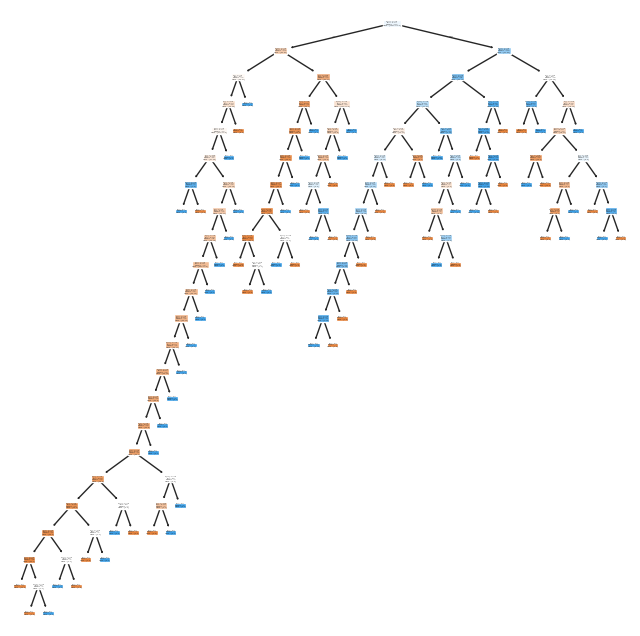

In [145]:
from sklearn import tree
plt.figure(figsize=[8,8])
tree.plot_tree(treemodel,filled=True)
plt.show()

In [146]:
from sklearn.metrics import accuracy_score,classification_report
accuracy_score(y_test,y_predic)*100

80.0

In [147]:
from sklearn.metrics import accuracy_score,classification_report
classification_report(y_predic,y_test)

'              precision    recall  f1-score   support\n\n           0       0.87      0.72      0.79        36\n           1       0.75      0.88      0.81        34\n\n    accuracy                           0.80        70\n   macro avg       0.81      0.80      0.80        70\nweighted avg       0.81      0.80      0.80        70\n'